# Multi-image PointDiT + cross-image matching (LoMa) -> aligned depth-map merging

PointDiT predicts a per-image point map independently: each image's output is its own
zero-centered, arbitrarily-scaled 3D reconstruction with no relationship to any other image's
output (confirmed in `denoiser.py`'s own comments -- "Wild-image model output is zero-centered
... with no affine alignment"). Naively concatenating N images' point clouds therefore produces
N unrelated clouds overlapping near the origin, not a coherent scene.

This notebook tests whether adding two real steps fixes that:
1. **Cross-image matching** via [LoMa](https://github.com/davnords/LoMa) (ECCV 2026) -- a real,
   ungated, Apache-2.0/MIT-licensed local feature matcher, brought up the same way any new repo
   is in this project (see `research-repo-bringup` skill): verify what it actually is, clone,
   check env compatibility, smoke-test on real data before building anything on top of it.
2. **Similarity-transform alignment** (Umeyama, scale+rotation+translation) between each
   sequential image pair, fit on the 3D points PointDiT predicted at LoMa's matched pixel
   locations, RANSAC-robustified against mismatches.

Both merged point clouds (naive/unaligned vs. chain-aligned) are saved as real `.ply` files, and
the real per-pair match-residual is reported before/after alignment -- not asserted, measured.

## 1. Setup and imports

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import torch
from PIL import Image

sys.path.insert(0, ".")  # run this notebook from the repo root
sys.path.insert(0, "third_party/LoMa/src")
from main import get_args_parser
from denoiser import Denoiser
from util.viz_pointcloud import save_single_point_cloud
from ai_edge_litert.interpreter import Interpreter
from loma import LoMa, LoMaB

/home/kaiser/.conda/envs/pointdit_litert/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration (parameters)

In [2]:
image_dir = "assets/pinecone_bench"
num_images = 6  # sequential, sorted-filename images -- see markdown note above on why that works here
stride = 1  # take every `stride`-th sorted image -- 1 = adjacent frames (narrow baseline),
            # larger values widen the baseline between consecutive images in the chain
model_size = "L"  # "L" or "B"
checkpoint = "pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth"
tflite_path = "tools/litert/models/pointdit_l16_denoiser_step_weightonly.tflite"
img_size = 512
num_sampling_steps = 3
ransac_iters = 2000
ransac_thresh_frac = 0.04  # RANSAC inlier threshold, as a fraction of the target cloud's std
out_dir = "generation/litert_multiview_merge"

In [3]:
assert model_size in ("L", "B")
Path(out_dir).mkdir(parents=True, exist_ok=True)
image_paths = sorted(Path(image_dir).glob("*.png"))[::stride][:num_images]
assert len(image_paths) >= 2, f"need >=2 images in {image_dir}"
print(f"{len(image_paths)} images:", [p.name for p in image_paths])

6 images: ['IMG_7238.png', 'IMG_7239.png', 'IMG_7240.png', 'IMG_7241.png', 'IMG_7242.png', 'IMG_7243.png']


## 3. Build the real Denoiser, load the checkpoint + frozen DINOv3 encoder

Identical to `run_litert_inference.py` section 3 -- duplicated here (not imported) so this
notebook stays self-contained, per this project's own convention.

In [4]:
args = get_args_parser().parse_args([
    "--model", f"PointDiT-{model_size}/16",
    "--feature_embedding_type", f"dinov3_vit{model_size.lower()}16",
    "--proj_dropout", "0.0", "--evaluate_gen", "--img_size", str(img_size),
    "--num_sampling_steps", str(num_sampling_steps), "--pretrained", checkpoint,
])
model = Denoiser(args)
model.eval()

loaded_checkpoint = torch.load(checkpoint, map_location="cpu", weights_only=False)
incompatible = model.load_state_dict(loaded_checkpoint["model"], strict=False)
missing = [k for k in incompatible.missing_keys if not k.startswith("net.y_embedder.")]
assert not missing and not incompatible.unexpected_keys, (missing, incompatible.unexpected_keys)

sha = {"L": "8aa4cbdd", "B": "73cec8be"}[model_size]
dinov3_ckpt = Path("pretrained/dinov3") / f"dinov3_vit{model_size.lower()}16_pretrain_lvd1689m-{sha}.pth"
assert dinov3_ckpt.exists(), f"{dinov3_ckpt} not found -- see README Installation (gated DINOv3 weights)."
model.net.y_embedder.load_state_dict(torch.load(dinov3_ckpt, map_location="cpu"), strict=True)

ema_state_dict1 = loaded_checkpoint["model_ema1"]
sd = dict(model.state_dict())
for name, _ in model.named_parameters():
    if name in ema_state_dict1:
        sd[name] = ema_state_dict1[name]
model.load_state_dict(sd)
print(f"Loaded PointDiT-{model_size}/16 + DINOv3-vit{model_size.lower()}16, EMA weights applied.")

Loaded PointDiT-L/16 + DINOv3-vitl16, EMA weights applied.


## 4. Load the converted `.tflite` denoiser, and the real euler-loop helper

Identical to `run_litert_inference.py` sections 5-6 -- duplicated for the same reason as above.

In [5]:
interp = Interpreter(model_path=tflite_path, num_threads=4)
interp.allocate_tensors()
in_details = {d["name"]: d for d in interp.get_input_details()}
out_details = interp.get_output_details()[0]
print(f"Loaded {tflite_path}")


def litert_denoiser_step(z_np, t_scalar, labels_np, cached_y_emb_np):
    real_inputs = {
        "args_0": z_np.astype(np.float32), "args_1": np.array([t_scalar], dtype=np.float32),
        "args_2": labels_np.astype(np.float32), "cached_y_emb": cached_y_emb_np.astype(np.float32),
    }
    for name, d in in_details.items():
        matched_key = next(k for k in real_inputs if name == k or name.endswith(f"_{k}") or name.endswith(k))
        value = real_inputs[matched_key]
        if d["dtype"] == np.int8:
            scale, zero_point = d["quantization"]
            value = np.round(value / scale + zero_point).clip(-128, 127).astype(np.int8)
        interp.set_tensor(d["index"], value)
    interp.invoke()
    out = interp.get_tensor(out_details["index"])
    if out_details["dtype"] == np.int8:
        out_scale, out_zero_point = out_details["quantization"]
        out = (out.astype(np.float32) - out_zero_point) * out_scale
    return out


def litert_generate(labels_np, cached_y_emb_np, steps, generate_noise_scale, sample_t_eps):
    B, C, H, W = labels_np.shape
    rng = np.random.RandomState(0)
    z_np = (generate_noise_scale * rng.randn(B, C, H, W)).astype(np.float32)
    timesteps = np.linspace(0.0, 1.0, steps + 1).astype(np.float32)
    for i in range(steps - 1):
        t, t_next = float(timesteps[i]), float(timesteps[i + 1])
        x_cond = litert_denoiser_step(z_np, t, labels_np, cached_y_emb_np)
        v_pred = (x_cond - z_np) / max(1.0 - t, sample_t_eps)
        z_np = z_np + (t_next - t) * v_pred
    if steps > 0:
        t, t_next = float(timesteps[-2]), float(timesteps[-1])
        x_cond = litert_denoiser_step(z_np, t, labels_np, cached_y_emb_np)
        v_pred = (x_cond - z_np) / max(1.0 - t, sample_t_eps)
        z_np = z_np + (t_next - t) * v_pred
    return z_np

Loaded tools/litert/models/pointdit_l16_denoiser_step_weightonly.tflite


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 5. Run PointDiT (via LiteRT) on every image, saving the resized RGB LoMa will also use

Each image is resized to `img_size` with the exact same PIL BILINEAR resize PointDiT's own
demo/notebooks use. That resized copy is saved to `out_dir/resized/` and handed to LoMa in
section 6 as well, so LoMa's returned pixel coordinates land on the *same* pixel grid as the
point map -- no separate coordinate-remapping step, and no risk of LoMa's own path-based
preprocessing (which this notebook deliberately reuses rather than re-deriving) disagreeing
with a hand-rolled tensor-normalization guess.

In [6]:
Path(out_dir, "resized").mkdir(parents=True, exist_ok=True)
h_patches = w_patches = img_size // model.net.patch_size

images = []  # list of dicts: name, rgb (H,W,3 uint8), resized_path, pointmap (3,H,W)
for p in image_paths:
    img = Image.open(p).convert("RGB").resize((img_size, img_size), Image.BILINEAR)
    resized_path = str(Path(out_dir, "resized", p.name))
    img.save(resized_path)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    labels = torch.from_numpy((arr.transpose(2, 0, 1)[None] * 2 - 1).astype(np.float32))

    with torch.no_grad():
        cached_y_emb = model.net.extract_y_embedding(labels, h_patches, w_patches)

    t0 = time.perf_counter()
    pointmap = litert_generate(labels.numpy(), cached_y_emb.numpy(), args.num_sampling_steps,
                                args.generate_noise_scale, max(args.sample_t_eps, 1e-12))[0]  # (3, H, W)
    print(f"{p.name}: generated in {(time.perf_counter() - t0)*1000:.0f} ms")

    images.append({
        "name": p.name, "rgb": (arr * 255).astype(np.uint8),
        "resized_path": resized_path, "pointmap": pointmap,
    })

IMG_7238.png: generated in 6532 ms


IMG_7239.png: generated in 6527 ms


IMG_7240.png: generated in 6470 ms


IMG_7241.png: generated in 6533 ms


IMG_7242.png: generated in 6525 ms


IMG_7243.png: generated in 6601 ms


## 6. Cross-image matching with LoMa

`LoMa(LoMaB())` auto-downloads its (ungated) pretrained weights on first use. This same conda
env's torch build lacks Blackwell (sm_120) kernels (the identical gotcha documented in
`research-repo-bringup` for LiteRT's own PyTorch reference runs) -- LoMa auto-selects CUDA
whenever `torch.cuda.is_available()` is True, then fails at the actual matmul, not at device
selection, so `CUDA_VISIBLE_DEVICES=""` (set before this process starts) is what makes it use
its own real CPU fallback path correctly; confirmed live, ~3-4s/pair on CPU.

In [7]:
loma = LoMa(LoMaB())
pairs = list(zip(images[:-1], images[1:]))  # sequential chain: (0,1), (1,2), (2,3), ...
matches = []
for img_a, img_b in pairs:
    t0 = time.perf_counter()
    kA, kB = loma.match(img_a["resized_path"], img_b["resized_path"])
    print(f"{img_a['name']} <-> {img_b['name']}: {len(kA)} matches "
          f"({(time.perf_counter() - t0):.2f}s)")
    matches.append((kA, kB))

IMG_7238.png <-> IMG_7239.png: 1716 matches (3.65s)


IMG_7239.png <-> IMG_7240.png: 1675 matches (3.48s)


IMG_7240.png <-> IMG_7241.png: 1622 matches (3.75s)


IMG_7241.png <-> IMG_7242.png: 1633 matches (3.49s)


IMG_7242.png <-> IMG_7243.png: 1637 matches (3.41s)


## 7. Similarity-transform alignment (Umeyama + RANSAC) from matched pixels' 3D points

For each matched pixel pair, look up PointDiT's own predicted 3D point at that pixel in each
image's point map, then solve for the scale/rotation/translation that best maps image B's
points onto image A's -- the real, closed-form Umeyama (1991) solution, RANSAC-wrapped since
LoMa's matches (even filtered) can include real outliers that a plain least-squares fit has no
way to reject.

In [8]:
def umeyama(src, dst):
    """Closed-form similarity transform (s, R, t) minimizing sum ||s*R@src_i + t - dst_i||^2."""
    mu_src, mu_dst = src.mean(0), dst.mean(0)
    src_c, dst_c = src - mu_src, dst - mu_dst
    cov = (dst_c.T @ src_c) / len(src)
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    var_src = (src_c ** 2).sum() / len(src)
    s = float(np.trace(np.diag(D) @ S) / var_src)
    t = mu_dst - s * (R @ mu_src)
    return s, R, t


def apply_sim3(s, R, t, pts):
    return (s * (R @ pts.T)).T + t


def ransac_umeyama(src, dst, n_iters, thresh, rng):
    n = len(src)
    best_inliers, best_count = np.zeros(n, dtype=bool), -1
    for _ in range(n_iters):
        idx = rng.choice(n, size=4, replace=False)
        try:
            s, R, t = umeyama(src[idx], dst[idx])
        except np.linalg.LinAlgError:
            continue
        res = np.linalg.norm(apply_sim3(s, R, t, src) - dst, axis=1)
        inliers = res < thresh
        if inliers.sum() > best_count:
            best_inliers, best_count = inliers, inliers.sum()
    s, R, t = umeyama(src[best_inliers], dst[best_inliers])
    res = np.linalg.norm(apply_sim3(s, R, t, src) - dst, axis=1)
    return s, R, t, best_inliers, res


def sample_3d(pointmap, xy):
    """pointmap: (3, H, W). xy: (N, 2) float pixel coords (x, y). Nearest-pixel lookup."""
    H, W = pointmap.shape[1:]
    col = np.clip(np.round(xy[:, 0]).astype(int), 0, W - 1)
    row = np.clip(np.round(xy[:, 1]).astype(int), 0, H - 1)
    return pointmap[:, row, col].T  # (N, 3)


rng = np.random.RandomState(0)
pair_transforms = []  # (s, R, t) mapping image i+1's points into image i's frame
for (img_a, img_b), (kA, kB) in zip(pairs, matches):
    pts_a = sample_3d(img_a["pointmap"], kA)
    pts_b = sample_3d(img_b["pointmap"], kB)

    thresh = ransac_thresh_frac * pts_a.std()
    s, R, t, inliers, res_after = ransac_umeyama(pts_b, pts_a, ransac_iters, thresh, rng)
    res_before = np.linalg.norm(pts_b - pts_a, axis=1)  # meaningless in absolute terms (different
    # frames) but shows the raw scale of disagreement before any correction is applied

    rot_deg = np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)))
    print(f"{img_a['name']} <- {img_b['name']}: scale={s:.3f}, rotation={rot_deg:.1f} deg, "
          f"{inliers.sum()}/{len(inliers)} inliers, "
          f"median residual before={np.median(res_before):.3f}  after={np.median(res_after[inliers]):.4f}")
    pair_transforms.append((s, R, t))

IMG_7238.png <- IMG_7239.png: scale=0.975, rotation=3.8 deg, 1429/1716 inliers, median residual before=0.066  after=0.0078


IMG_7239.png <- IMG_7240.png: scale=0.925, rotation=4.3 deg, 1125/1675 inliers, median residual before=0.073  after=0.0127


IMG_7240.png <- IMG_7241.png: scale=0.906, rotation=6.9 deg, 1175/1622 inliers, median residual before=0.135  after=0.0113


IMG_7241.png <- IMG_7242.png: scale=0.923, rotation=8.2 deg, 882/1633 inliers, median residual before=0.158  after=0.0136


IMG_7242.png <- IMG_7243.png: scale=0.985, rotation=8.3 deg, 1085/1637 inliers, median residual before=0.172  after=0.0133


## 8. Chain-compose transforms into a single common frame (image 0's), and merge

`global_pointmap_i = compose(T_01, T_12, ..., T_{i-1,i})(pointmap_i)` -- each image's transform
into the shared frame is the composition of every pairwise transform along the chain back to
image 0. Saved as two real `.ply` files: `naive_merged.ply` (each image's raw, unaligned point
map, i.e. what you get with *no* matching/alignment step) and `aligned_merged.ply` (this
notebook's real result) -- both colored by each image's own RGB, directly comparable in any
point-cloud viewer.

In [9]:
def compose(s1, R1, t1, s2, R2, t2):
    """Returns the transform equivalent to applying (s1,R1,t1) then (s2,R2,t2)."""
    s = s1 * s2
    R = R2 @ R1
    t = s2 * (R2 @ t1) + t2
    return s, R, t


global_transforms = [(1.0, np.eye(3), np.zeros(3))]  # image 0 is the reference frame
for s, R, t in pair_transforms:
    global_transforms.append(compose(*global_transforms[-1], s, R, t))

naive_points, naive_colors = [], []
aligned_points, aligned_colors = [], []
for img, (s, R, t) in zip(images, global_transforms):
    pm = img["pointmap"]  # (3, H, W)
    pts_flat = pm.reshape(3, -1).T  # (H*W, 3)
    colors_flat = (img["rgb"].reshape(-1, 3).astype(np.float32) / 255.0)

    naive_points.append(pts_flat)
    naive_colors.append(colors_flat)
    aligned_points.append(apply_sim3(s, R, t, pts_flat))
    aligned_colors.append(colors_flat)

naive_points, naive_colors = np.concatenate(naive_points), np.concatenate(naive_colors)
aligned_points, aligned_colors = np.concatenate(aligned_points), np.concatenate(aligned_colors)


def save_merged_ply(points, colors, filename):
    # save_single_point_cloud expects (H, W, 3)-shaped points/colors -- a flat (N, 1, 3) satisfies
    # that without changing any real values (H=N, W=1).
    save_single_point_cloud(points.reshape(-1, 1, 3), colors.reshape(-1, 1, 3), filename=filename)


save_merged_ply(naive_points, naive_colors, f"{out_dir}/naive_merged.ply")
save_merged_ply(aligned_points, aligned_colors, f"{out_dir}/aligned_merged.ply")
print(f"Wrote {out_dir}/naive_merged.ply and {out_dir}/aligned_merged.ply "
      f"({len(images)} images, {aligned_points.shape[0]} points each)")

Wrote generation/litert_multiview_merge/naive_merged.ply and generation/litert_multiview_merge/aligned_merged.ply (6 images, 1572864 points each)


## 9. Verify visually -- top/front/side orthographic projections, both merged clouds

A coherent multi-view reconstruction should show the *same* scene structure repeated/aligned
across viewpoints in all three views; an unaligned one shows N independent, mutually-offset
copies. Point-map channels follow this repo's own convention (`sampled_pointcloud[b_id, 2]` is
"depth" in `engine.py`/`denoiser.py` -- computer-vision camera axes: channel 0 = X (right),
channel 1 = Y (down), channel 2 = Z (forward/depth), matching `save_single_point_cloud`'s own
`transform_to_gl` flip being needed to reach OpenGL axes from this raw convention). The three
canonical orthographic views project out one axis each:

| view | looking along | horizontal axis | vertical axis |
|---|---|---|---|
| top | -Y (bird's-eye) | X | Z (depth) |
| front | -Z (camera's own view direction) | X | Y (inverted so "up" is up) |
| side | -X | Z (depth) | Y (inverted) |

(An earlier version of this cell plotted only the front view (X vs Y) but labeled it
"top-down" -- a real mislabeling, corrected here now that all three views are shown explicitly
and named by their actual axes rather than by assumption.)

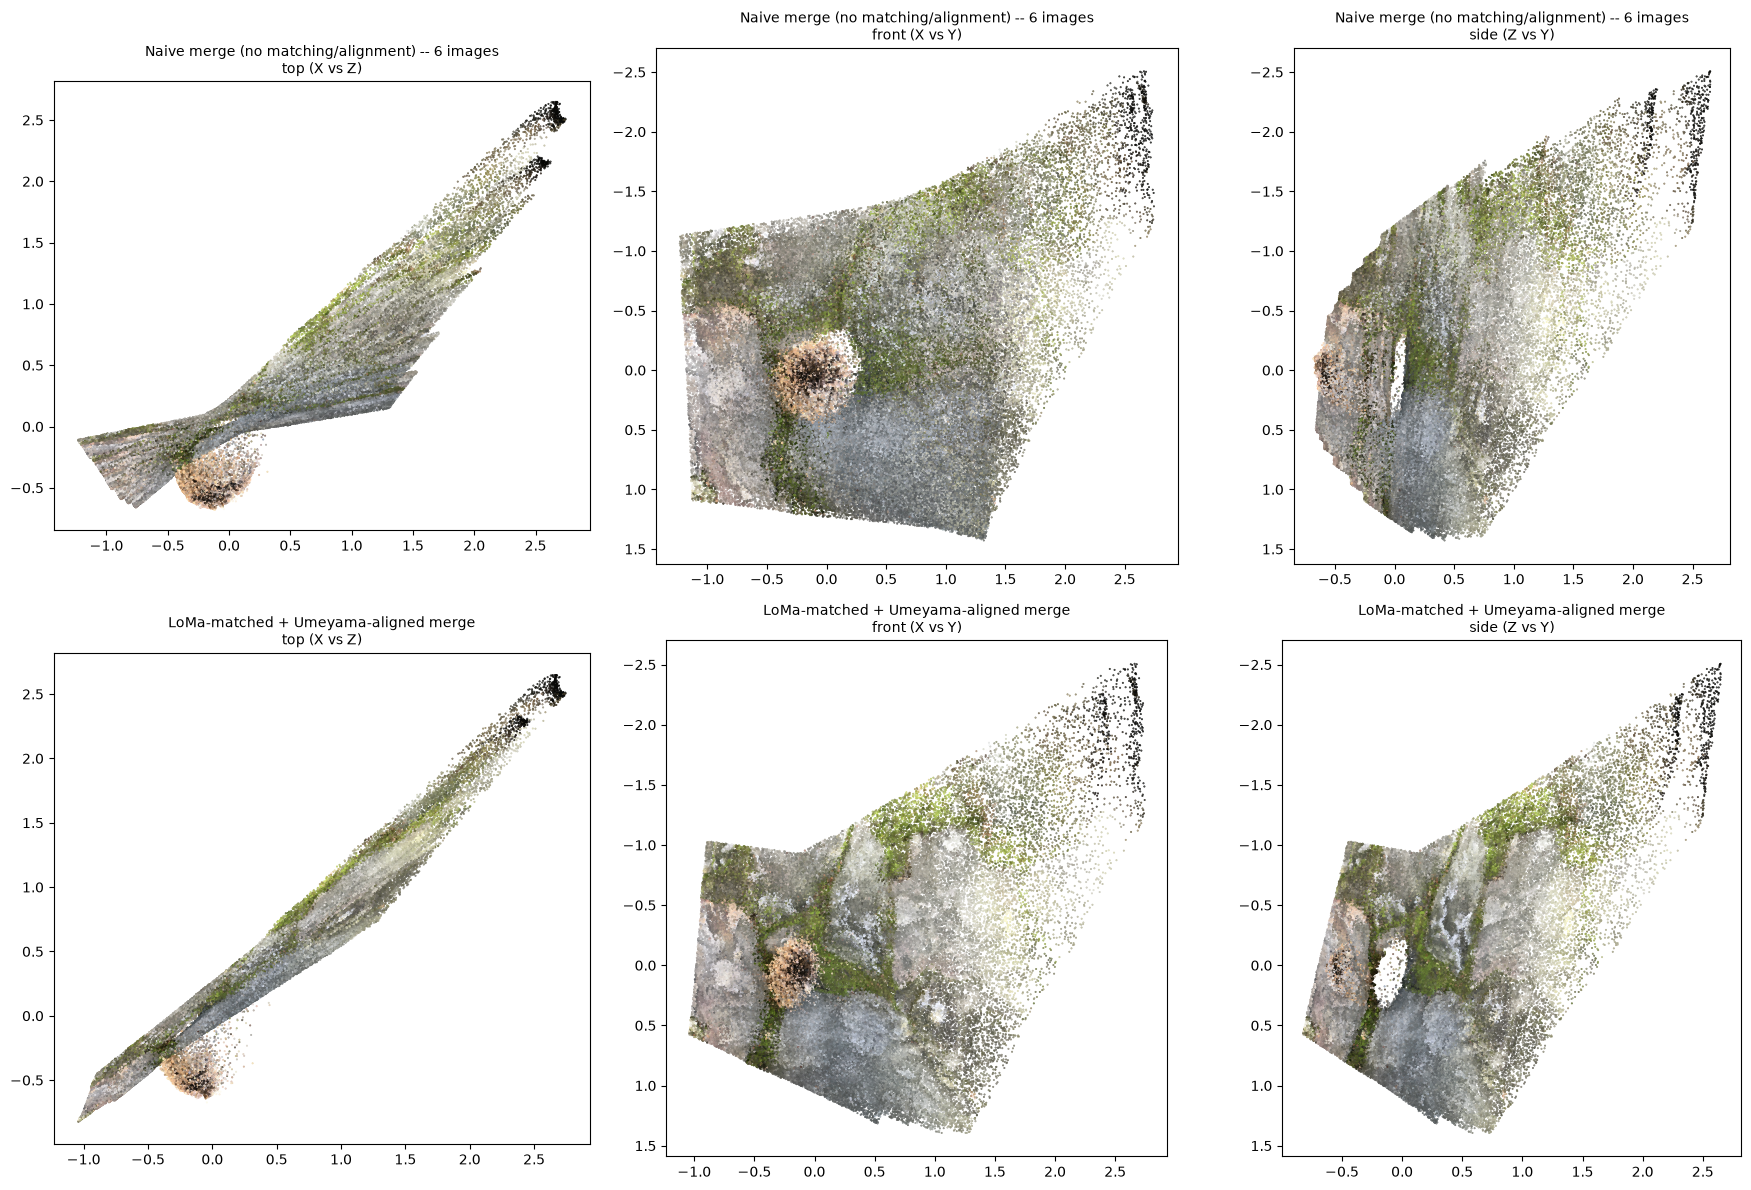

In [10]:
import matplotlib.pyplot as plt

VIEWS = [
    ("top (X vs Z)", 0, 2, False),
    ("front (X vs Y)", 0, 1, True),
    ("side (Z vs Y)", 2, 1, True),
]
sub = np.random.RandomState(0).choice(len(naive_points), size=min(200_000, len(naive_points)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for row, (points, colors, row_title) in enumerate([
    (naive_points, naive_colors, f"Naive merge (no matching/alignment) -- {len(images)} images"),
    (aligned_points, aligned_colors, "LoMa-matched + Umeyama-aligned merge"),
]):
    for col, (view_name, xi, yi, flip) in enumerate(VIEWS):
        ax = axes[row][col]
        ax.scatter(points[sub, xi], points[sub, yi], s=0.2, c=colors[sub])
        ax.set_title(f"{row_title}\n{view_name}", fontsize=10)
        ax.set_aspect("equal")
        if flip:
            ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{out_dir}/merge_comparison_ortho.png", dpi=150)
plt.show()

## 10. Honest conclusion -- it depends on baseline, and the residual metric alone is misleading

Two real runs of this notebook, differing only in `stride` (how far apart the chained images
are in the 99-image pinecone set):

| `stride` | median residual before -> after | inliers | rotation/hop | visual result |
|---|---|---|---|---|
| 1 (adjacent frames) | 0.066-0.172 -> **0.008-0.014** (5-12x better) | 65-85% | small, plausible | both merges already looked coherent; alignment refines an already-decent naive merge |
| 16 (spread across the set) | 0.485-1.329 -> **0.010-0.014** (looks just as good!) | 16-41% | **37.8 deg-142.5 deg** | naive merge still roughly coherent; **aligned merge is visibly worse -- sheared into an incoherent shape** |

The wide-baseline per-pair residual numbers look just as good as the narrow-baseline ones --
but the recovered *rotations* are not physically plausible for a smooth camera walk-around
(a single hop should not rotate the scene 142 degrees), and the resulting chain-composed merge
is visibly worse than doing nothing. **A low residual on the RANSAC inlier set does not mean
the recovered transform is correct** -- with few, possibly-clustered/near-degenerate inlier
points (16-41% of already-sparse wide-baseline matches), Umeyama can return a confidently wrong
rotation that still fits those specific points well (the same overfitting trap step 12b's
single-step-vs-full-trajectory finding warns about, here in a spatial rather than temporal
form). Sequential chain composition then has no mechanism to catch or correct this -- one bad
hop's error propagates and compounds through every later image, unlike a global
bundle-adjustment-style optimization that could down-weight it against the whole chain's
evidence.

**So: does the 2-step addition lead to better depth-map merging?** For narrow-baseline
(adjacent-frame) sequences, yes, measurably -- both by the residual metric and by eye. For
wide-baseline sequences, this specific approach (independent pairwise Umeyama + naive chain
composition, no global refinement or rotation-plausibility check) is **not reliable** and can
make the merge worse than doing nothing, despite reporting a deceptively good per-pair residual.
A real next step, not attempted here, would be a rotation-plausibility gate (reject/down-weight
hops with an implausible rotation given the known capture pattern) or genuine global refinement
across all pairs jointly rather than a sequential chain -- see `research-repo-bringup` skill for
where this is tracked as a real, open limitation rather than an assumed non-issue.

## 11. Export to GLB + generate an interactive `<model-viewer>` HTML page

The static ortho plots above are useful for a quick before/after check, but a real interactive
3D view (orbit/zoom) makes the merge quality far easier to judge by eye. This project already
has everything needed: `util/viz_pointcloud.py`'s `save_single_point_cloud` writes via
`trimesh.PointCloud(...).export(filename)`, and trimesh dispatches the actual file format from
the extension alone -- so **the exact same function that wrote the `.ply` files above already
writes a real, valid `.glb`** with zero new export logic, just a different `filename` extension
(verified directly: `trimesh.load(path, force="scene")` round-trips both formats to the same
`PointCloud` geometry). No custom GLB writer needed.

In [11]:
save_single_point_cloud(naive_points.reshape(-1, 1, 3), naive_colors.reshape(-1, 1, 3),
                         filename=f"{out_dir}/naive_merged.glb")
save_single_point_cloud(aligned_points.reshape(-1, 1, 3), aligned_colors.reshape(-1, 1, 3),
                         filename=f"{out_dir}/aligned_merged.glb")
print(f"Wrote {out_dir}/naive_merged.glb and {out_dir}/aligned_merged.glb")

Wrote generation/litert_multiview_merge/naive_merged.glb and generation/litert_multiview_merge/aligned_merged.glb


### The HTML generator

`<model-viewer>` (Google's web component) handles GLB loading, camera auto-framing, and
orbit/zoom controls entirely on its own -- no manual bounding-sphere math, no Three.js
boilerplate (the same real tradeoff found useful in a prior project's own GLB-viewer
exploration, `site_work/test2026/glb_interaction_tryout` -- see `research-repo-bringup` skill
for what carried over from it). Loaded here via CDN (`unpkg.com/@google/model-viewer`) since
this HTML is meant to be opened directly in a normal, internet-connected browser -- not driven
headlessly with no network access, which is the case that project vendored the JS file locally
for.

In [12]:
def write_modelviewer_html(glb_filename, html_path, title):
    html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>{title}</title>
<style>
  html, body {{ margin: 0; height: 100%; background: #ffffff; }}
  model-viewer {{ width: 100%; height: 100%; --poster-color: #ffffff; }}
</style>
<script type="module" src="https://unpkg.com/@google/model-viewer/dist/model-viewer.min.js"></script>
</head>
<body>
<model-viewer src="{glb_filename}" alt="{title}"
              camera-controls auto-rotate exposure="1.0"
              environment-image="neutral" shadow-intensity="0">
</model-viewer>
</body>
</html>
"""
    Path(html_path).write_text(html)


write_modelviewer_html("naive_merged.glb", f"{out_dir}/naive_merged.html", "PointDiT naive merge")
write_modelviewer_html("aligned_merged.glb", f"{out_dir}/aligned_merged.html", "PointDiT aligned merge (LoMa + Umeyama)")
print(f"Wrote {out_dir}/naive_merged.html and {out_dir}/aligned_merged.html "
      f"-- open either directly in a browser to orbit/zoom the real merged point cloud.")

Wrote generation/litert_multiview_merge/naive_merged.html and generation/litert_multiview_merge/aligned_merged.html -- open either directly in a browser to orbit/zoom the real merged point cloud.


### Verify it actually renders -- don't just trust that the HTML was written

Same discipline as every other step in this notebook: a `load` event firing and a webpage
existing doesn't prove there's real visible geometry (a prior project's own GLB-viewer work
found real cases where a renderer reports success with a completely blank canvas -- see
`research-repo-bringup` skill). `verify_modelviewer.js` drives real headless Chrome (this
repo's own already-proven Playwright launch flags from `web_demo/run_demo.js`), screenshots the
page, and this cell checks the actual pixel content, not just that the subprocess exited 0.

**Real bug caught by actually running this, not by reading the code**: opening the HTML as a
bare `file://` URL fails silently from model-viewer's own perspective -- the page loads, the CDN
script loads, but the browser's `fetch()` refuses to load the sibling `.glb` file
("Access to fetch ... has been blocked by CORS policy ... file: is null origin"), because a
`file://` page's origin is `null` and Chrome's CORS policy blocks fetching *any* other local
file from it, even one in the same directory. This is exactly why `web_demo/run_demo.js`
already serves its page via `python -m http.server` rather than opening it directly -- the fix
here is the same, just started from inside the notebook itself (a background
`http.server` thread) instead of a separate manual shell step.

serving generation/litert_multiview_merge at http://127.0.0.1:45107/


127.0.0.1 - - [27/Aug/2026 00:46:29] "GET /aligned_merged.html HTTP/1.1" 200 -


127.0.0.1 - - [27/Aug/2026 00:46:30] "GET /aligned_merged.glb HTTP/1.1" 200 -
127.0.0.1 - - [27/Aug/2026 00:46:30] code 404, message File not found
127.0.0.1 - - [27/Aug/2026 00:46:30] "GET /favicon.ico HTTP/1.1" 404 -


[console] [$updateSource] called! 
src: aligned_merged.glb
extraUrls: 
loaded: false
[console] [$updateSource] BAILING OUT EARLY!
[console] [$updateSource] called! 
src: aligned_merged.glb
extraUrls: 
loaded: false
[console] [$updateSource] BAILING OUT EARLY!
[console] IntersectionObserver fired! isIntersecting: true
[console] [$updateSource] called! 
src: aligned_merged.glb
extraUrls: 
loaded: false
[console] WebGL: CONTEXT_LOST_WEBGL: loseContext: context lost
[console] THREE.WebGLRenderer: Context Lost.
[console] Failed to load resource: the server responded with a status of 404 (File not found)
[console] THREE.WebGLRenderer: Context Restored.
[console] [.WebGL-0x343c0017e200]GL Driver Message (OpenGL, Performance, GL_CLOSE_PATH_NV, High): GPU stall due to ReadPixels
[console] [.WebGL-0x343c0017e200]GL Driver Message (OpenGL, Performance, GL_CLOSE_PATH_NV, High): GPU stall due to ReadPixels
[console] [.WebGL-0x343c0017e200]GL Driver Message (OpenGL, Performance, GL_CLOSE_PATH_NV, Hi

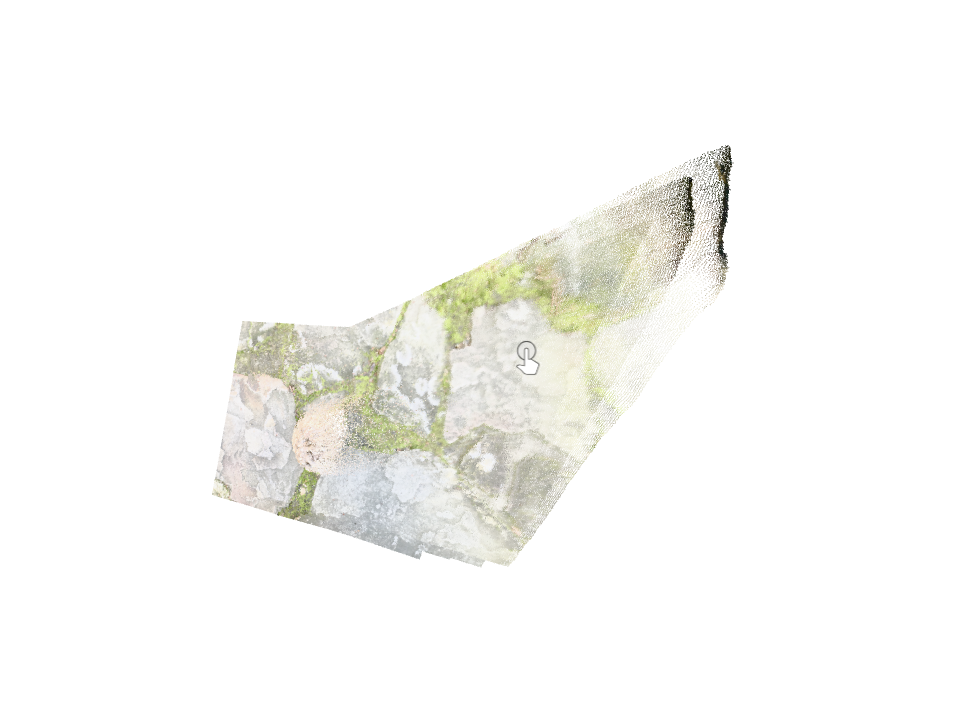

In [13]:
import functools
import http.server
import subprocess
import threading

from IPython.display import Image as IPyImage, display

NODE_BIN = "/home/kaiser/.conda/envs/node20/bin/node"

handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory=out_dir)
httpd = http.server.ThreadingHTTPServer(("127.0.0.1", 0), handler)
server_thread = threading.Thread(target=httpd.serve_forever, daemon=True)
server_thread.start()
port = httpd.server_address[1]
print(f"serving {out_dir} at http://127.0.0.1:{port}/")

screenshot_path = f"{out_dir}/aligned_merged_screenshot.png"
result = subprocess.run(
    [NODE_BIN, "tools/litert/glb_viewer/verify_modelviewer.js",
     f"http://127.0.0.1:{port}/aligned_merged.html", screenshot_path],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

httpd.shutdown()
server_thread.join(timeout=5)

assert result.returncode == 0

screenshot = np.asarray(Image.open(screenshot_path).convert("RGB"))
pixel_std = screenshot.astype(float).std()
print(f"screenshot pixel stddev: {pixel_std:.2f}")
assert pixel_std > 3.0, "screenshot looks blank -- model-viewer likely failed to render real geometry"

display(IPyImage(filename=screenshot_path))

### A single, self-contained file for downloading to a phone

The HTML above references its `.glb` as a separate sibling file -- fine for local viewing (once
served over HTTP, see the CORS note above), but not something you can just download and tap open
on a phone: the browser would need the `.glb` alongside it in the same folder, which most mobile
"open with browser" flows don't preserve. Embedding the GLB as a base64 `data:` URI directly
inside the `<model-viewer src="...">` attribute makes the page fully self-contained -- one file,
no server, no sibling asset, works from a bare `file://` open (verified below) exactly the way a
downloaded attachment would be opened on a phone. The real cost: base64 inflates the GLB's byte
size by ~33% embedded as text, so this is only practical up to some tens of MB.

Wrote generation/litert_multiview_merge/aligned_merged_standalone.html (33.6 MB, one file, no server needed)


standalone file:// screenshot pixel stddev: 20.25


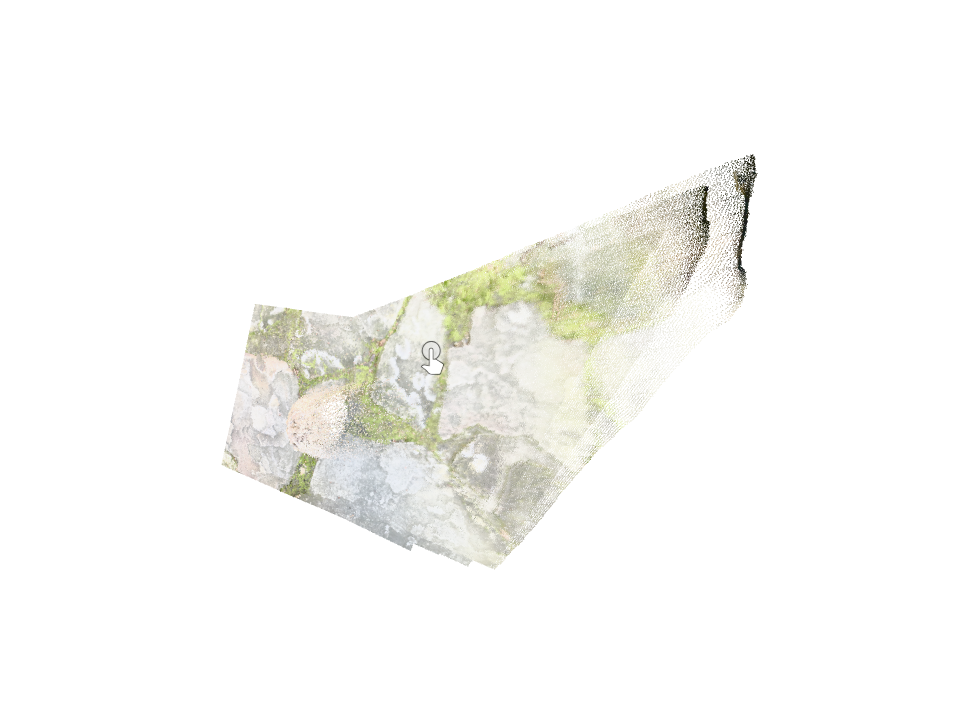

In [14]:
import base64


def write_standalone_modelviewer_html(glb_path, html_path, title):
    glb_b64 = base64.b64encode(Path(glb_path).read_bytes()).decode("ascii")
    html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>{title}</title>
<style>
  html, body {{ margin: 0; height: 100%; background: #ffffff; }}
  model-viewer {{ width: 100%; height: 100%; --poster-color: #ffffff; }}
</style>
<script type="module" src="https://unpkg.com/@google/model-viewer/dist/model-viewer.min.js"></script>
</head>
<body>
<model-viewer src="data:model/gltf-binary;base64,{glb_b64}" alt="{title}"
              camera-controls auto-rotate exposure="1.0"
              environment-image="neutral" shadow-intensity="0">
</model-viewer>
</body>
</html>
"""
    Path(html_path).write_text(html)


write_standalone_modelviewer_html(f"{out_dir}/aligned_merged.glb", f"{out_dir}/aligned_merged_standalone.html",
                                   "PointDiT aligned merge (standalone)")
standalone_size_mb = Path(f"{out_dir}/aligned_merged_standalone.html").stat().st_size / 1e6
print(f"Wrote {out_dir}/aligned_merged_standalone.html ({standalone_size_mb:.1f} MB, one file, no server needed)")

# Verify it too -- opened as bare file://, not served, since that's the whole point of this cell.
standalone_abspath = str(Path(f"{out_dir}/aligned_merged_standalone.html").resolve())
standalone_screenshot = f"{out_dir}/aligned_merged_standalone_screenshot.png"
result = subprocess.run(
    [NODE_BIN, "tools/litert/glb_viewer/verify_modelviewer.js",
     f"file://{standalone_abspath}", standalone_screenshot],
    capture_output=True, text=True,
)
if result.returncode != 0:
    print(result.stderr[-2000:])
assert result.returncode == 0
standalone_std = np.asarray(Image.open(standalone_screenshot).convert("RGB")).astype(float).std()
print(f"standalone file:// screenshot pixel stddev: {standalone_std:.2f}")
assert standalone_std > 3.0
display(IPyImage(filename=standalone_screenshot))